# Convergence Analysis for Colonel Blotto Simulations

This notebook analyzes the time to convergence for various match-ups in the Colonel Blotto game.

**Convergence Criteria:**
- **Retaining games**: Troop counts remain constant for 5 consecutive steps
- **Non-retaining games**: Average utility stabilizes (standard deviation < 1% of mean over a rolling window)

**Output metrics**: Mean and variance of convergence time across all simulations for each match-up

In [2]:
%pip install pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import Tuple, Dict, List
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   -------- ------------------------------- 2.1/9.9 MB 20.7 MB/s eta 0:00:01
   ----------------------------- ---------- 7.3/9.9 MB 25.4 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 22.9 MB/s  0:00:00
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)

   ---------------------------------------- 0/3 [tzdata]
   ---------------------------------------- 0/3 [tzdata]
   ------------- -------------------------- 1/3 [pandas]
   ------------- -------------------------- 1/3 [pandas]
   ------------- -------------------------- 1/3 [pandas]
   ------------- -------------------------- 1/3 [pandas]
   ------------- -------------------------- 1/3 [pandas]
   ------------- -------------------------- 1/3 [pandas]
   ------------- -------------------------- 1/3 [pandas]
   ------------- -------------------------- 1/3 [pandas]
   ----------

In [ ]:
# Configuration
RESULTS_DIR = Path('results')
RETAINING_CONSECUTIVE_STEPS = 5  # Number of consecutive steps for retaining convergence
NON_RETAINING_WINDOW = 5  # Rolling window size for non-retaining convergence
NON_RETAINING_THRESHOLD = 0.025  # 1% threshold for utility stabilization

print(f"Results directory: {RESULTS_DIR}")
print(f"Retaining convergence criterion: {RETAINING_CONSECUTIVE_STEPS} consecutive constant steps")
print(f"Non-retaining convergence criterion: stdev < {NON_RETAINING_THRESHOLD*100}% of mean over {NON_RETAINING_WINDOW} step window")

Results directory: results
Retaining convergence criterion: 5 consecutive constant steps
Non-retaining convergence criterion: stdev < 2.5% of mean over 5 step window


## Helper Functions

In [23]:
def calculate_troop_counts(df: pd.DataFrame) -> pd.DataFrame:
    """
    Calculate running troop counts for each player in a retaining game.
    """
    # Get initial troop counts from first row
    # Assuming natt and ndef are the same across the simulation
    initial_troops = 10  # This could be extracted from filename if needed
    
    # Sort by sim_id and stage
    df = df.sort_values(['sim_id', 'stage']).copy()
    
    # Calculate cumulative troop changes
    df['attacker_troops'] = initial_troops
    df['defender_troops'] = initial_troops
    
    for sim_id in df['sim_id'].unique():
        mask = df['sim_id'] == sim_id
        sim_data = df[mask].copy()
        
        attacker_troops = [initial_troops]
        defender_troops = [initial_troops]
        
        for i, row in enumerate(sim_data.itertuples()):
            if i > 0:
                # Attacker loses captured troops, gains defender's captured troops
                new_att = attacker_troops[-1] - row.attacker_troops_captured + row.defender_troops_captured
                # Defender loses captured troops, gains attacker's captured troops  
                new_def = defender_troops[-1] - row.defender_troops_captured + row.attacker_troops_captured
                attacker_troops.append(new_att)
                defender_troops.append(new_def)
        
        df.loc[mask, 'attacker_troops'] = attacker_troops
        df.loc[mask, 'defender_troops'] = defender_troops
    
    return df

In [24]:
def find_retaining_convergence(sim_df: pd.DataFrame) -> int:
    """
    Find the step at which troop counts converge (remain constant for N consecutive steps).
    Returns the step number, or -1 if convergence not reached.
    """
    sim_df = sim_df.sort_values('stage')
    
    attacker_troops = sim_df['attacker_troops'].values
    defender_troops = sim_df['defender_troops'].values
    stages = sim_df['stage'].values
    
    if len(attacker_troops) < RETAINING_CONSECUTIVE_STEPS:
        return -1
    
    # Check for consecutive constant values
    for i in range(len(attacker_troops) - RETAINING_CONSECUTIVE_STEPS + 1):
        att_window = attacker_troops[i:i+RETAINING_CONSECUTIVE_STEPS]
        def_window = defender_troops[i:i+RETAINING_CONSECUTIVE_STEPS]
        
        # Check if all values in window are the same
        if (np.all(att_window == att_window[0]) and 
            np.all(def_window == def_window[0])):
            return stages[i + RETAINING_CONSECUTIVE_STEPS - 1]  # Return the last step of convergence window
    
    return -1  # Not converged

In [25]:
def find_non_retaining_convergence(sim_df: pd.DataFrame) -> int:
    """
    Find the step at which utility converges (stabilizes within threshold).
    Returns the step number, or -1 if convergence not reached.
    """
    sim_df = sim_df.sort_values('stage')
    
    utility = sim_df['utility_current'].values
    stages = sim_df['stage'].values
    
    if len(utility) < NON_RETAINING_WINDOW:
        return -1
    
    # Check rolling window for stability
    for i in range(len(utility) - NON_RETAINING_WINDOW + 1):
        window = utility[i:i+NON_RETAINING_WINDOW]
        mean_util = np.mean(window)
        std_util = np.std(window)
        
        # Check if standard deviation is less than threshold % of mean
        # Handle case where mean is 0 or very small
        if mean_util == 0:
            # If mean is 0, consider converged if std is also near 0
            if std_util < 0.01:
                return stages[i + NON_RETAINING_WINDOW - 1]
        else:
            relative_std = std_util / abs(mean_util)
            if relative_std < NON_RETAINING_THRESHOLD:
                return stages[i + NON_RETAINING_WINDOW - 1]
    
    return -1  # Not converged

## Load and Process All Result Files

In [26]:
# Get all CSV files and filter for dp_exploit and dp_nash only (non-retaining games)
all_csv_files = sorted(RESULTS_DIR.glob('*.csv'))
print(f"Found {len(all_csv_files)} total result files")

# Filter for only dp_exploit and dp_nash games that are non-retaining
csv_files = [f for f in all_csv_files if 
             ('dp_exploit' in f.name or 'dp_nash' in f.name) and 
             'retain-False' in f.name]
print(f"Filtered to {len(csv_files)} non-retaining files with dp_exploit or dp_nash controllers")

# Show all filenames (should be a small set now)
print("\nFiles to analyze:")
for f in csv_files:
    print(f"  {f.name}")

Found 1296 total result files
Filtered to 360 non-retaining files with dp_exploit or dp_nash controllers

Files to analyze:
  att-dp_exploit__def-dp_exploit__sims-1000__steps-100__natt-10__ndef-10__m-0.25__p-1.0__alpha-0.5__c0-0.25__retain-False.csv
  att-dp_exploit__def-dp_exploit__sims-1000__steps-100__natt-10__ndef-10__m-0.5__p-1.0__alpha-0.1__c0-0.25__retain-False.csv
  att-dp_exploit__def-dp_exploit__sims-1000__steps-100__natt-10__ndef-10__m-0.5__p-1.0__alpha-0.3__c0-0.25__retain-False.csv
  att-dp_exploit__def-dp_exploit__sims-1000__steps-100__natt-10__ndef-10__m-0.5__p-1.0__alpha-0.5__c0-0.0__retain-False.csv
  att-dp_exploit__def-dp_exploit__sims-1000__steps-100__natt-10__ndef-10__m-0.5__p-1.0__alpha-0.5__c0-0.25__retain-False.csv
  att-dp_exploit__def-dp_exploit__sims-1000__steps-100__natt-10__ndef-10__m-0.5__p-1.0__alpha-0.5__c0-0.5__retain-False.csv
  att-dp_exploit__def-dp_exploit__sims-1000__steps-100__natt-10__ndef-10__m-0.5__p-1.0__alpha-0.7__c0-0.25__retain-False.csv
  

In [27]:
def analyze_convergence_for_file(filepath: Path) -> Dict:
    """
    Analyze convergence for all simulations in a single CSV file.
    Returns dictionary with convergence statistics.
    """
    df = pd.read_csv(filepath)
    
    # Extract metadata from first row
    meta = df.iloc[0]
    retain = meta['retain']
    attacker = meta['attacker_controller']
    defender = meta['defender_controller']
    alpha = meta['alpha']
    m = meta['m']
    c0 = meta['c0']
    
    convergence_times = []
    
    if retain:
        # Calculate troop counts for retaining game
        df = calculate_troop_counts(df)
    
    # Analyze each simulation
    for sim_id in df['sim_id'].unique():
        sim_df = df[df['sim_id'] == sim_id]
        
        if retain:
            conv_time = find_retaining_convergence(sim_df)
        else:
            conv_time = find_non_retaining_convergence(sim_df)
        
        if conv_time > 0:
            convergence_times.append(conv_time)
    
    # Calculate statistics
    result = {
        'filename': filepath.name,
        'attacker': attacker,
        'defender': defender,
        'retain': retain,
        'alpha': alpha,
        'm': m,
        'c0': c0,
        'total_sims': len(df['sim_id'].unique()),
        'converged_sims': len(convergence_times),
        'convergence_rate': len(convergence_times) / len(df['sim_id'].unique()) if len(df['sim_id'].unique()) > 0 else 0,
        'mean_convergence_time': np.mean(convergence_times) if convergence_times else np.nan,
        'variance_convergence_time': np.var(convergence_times) if convergence_times else np.nan,
        'std_convergence_time': np.std(convergence_times) if convergence_times else np.nan,
        'median_convergence_time': np.median(convergence_times) if convergence_times else np.nan,
        'min_convergence_time': np.min(convergence_times) if convergence_times else np.nan,
        'max_convergence_time': np.max(convergence_times) if convergence_times else np.nan,
    }
    
    return result

In [28]:
# Analyze all files
print("Analyzing convergence for all files...")
results = []

for i, filepath in enumerate(csv_files):
    if (i + 1) % 10 == 0:
        print(f"  Processed {i + 1}/{len(csv_files)} files...")
    
    try:
        result = analyze_convergence_for_file(filepath)
        results.append(result)
    except Exception as e:
        print(f"  Error processing {filepath.name}: {e}")

print(f"\nCompleted analysis of {len(results)} files")

# Create results dataframe
results_df = pd.DataFrame(results)
results_df.head(10)

Analyzing convergence for all files...
  Processed 10/360 files...
  Processed 20/360 files...
  Processed 30/360 files...
  Processed 40/360 files...
  Processed 50/360 files...
  Processed 60/360 files...
  Processed 70/360 files...
  Processed 80/360 files...
  Processed 90/360 files...
  Processed 100/360 files...
  Processed 110/360 files...
  Processed 120/360 files...
  Processed 130/360 files...
  Processed 140/360 files...
  Processed 150/360 files...
  Processed 160/360 files...
  Processed 170/360 files...
  Processed 180/360 files...
  Processed 190/360 files...
  Processed 200/360 files...
  Processed 210/360 files...
  Processed 220/360 files...
  Processed 230/360 files...
  Processed 240/360 files...
  Processed 250/360 files...
  Processed 260/360 files...
  Processed 270/360 files...
  Processed 280/360 files...
  Processed 290/360 files...
  Processed 300/360 files...
  Processed 310/360 files...
  Processed 320/360 files...
  Processed 330/360 files...
  Processed 3

,filename,attacker,defender,retain,alpha,m,c0,total_sims,converged_sims,convergence_rate,mean_convergence_time,variance_convergence_time,std_convergence_time,median_convergence_time,min_convergence_time,max_convergence_time
0,att-dp_exploit__def-dp_exploit__sims-1000__ste...,dp_exploit,dp_exploit,False,0.5,0.25,0.25,1000,1000,1.0,10.347,36.778591,6.064536,9.0,5.0,51.0
1,att-dp_exploit__def-dp_exploit__sims-1000__ste...,dp_exploit,dp_exploit,False,0.1,0.50,0.25,1000,1000,1.0,16.403,172.214591,13.123056,12.0,5.0,90.0
2,att-dp_exploit__def-dp_exploit__sims-1000__ste...,dp_exploit,dp_exploit,False,0.3,0.50,0.25,1000,1000,1.0,15.603,147.811391,12.157771,12.0,5.0,77.0
3,att-dp_exploit__def-dp_exploit__sims-1000__ste...,dp_exploit,dp_exploit,False,0.5,0.50,0.00,1000,1000,1.0,11.836,84.249104,9.178731,9.0,5.0,77.0
4,att-dp_exploit__def-dp_exploit__sims-1000__ste...,dp_exploit,dp_exploit,False,0.5,0.50,0.25,1000,1000,1.0,12.514,84.059804,9.168413,10.0,5.0,64.0
5,att-dp_exploit__def-dp_exploit__sims-1000__ste...,dp_exploit,dp_exploit,False,0.5,0.50,0.50,1000,1000,1.0,12.787,83.899631,9.159674,10.0,5.0,64.0
6,att-dp_exploit__def-dp_exploit__sims-1000__ste...,dp_exploit,dp_exploit,False,0.7,0.50,0.25,1000,1000,1.0,14.436,112.369904,10.600467,11.0,5.0,86.0
7,att-dp_exploit__def-dp_exploit__sims-1000__ste...,dp_exploit,dp_exploit,False,0.9,0.50,0.25,1000,1000,1.0,10.985,86.150775,9.281744,6.0,5.0,72.0
8,att-dp_exploit__def-dp_exploit__sims-1000__ste...,dp_exploit,dp_exploit,False,0.5,0.75,0.25,1000,1000,1.0,11.067,59.838511,7.735536,9.0,5.0,63.0
9,att-dp_exploit__def-dp_exploit__sims-1000__ste...,dp_exploit,dp_exploit,False,0.5,1.00,0.25,1000,1000,1.0,6.639,8.670679,2.944602,5.0,5.0,27.0


## Summary Statistics

In [29]:
# Overall summary
print("="*80)
print("OVERALL CONVERGENCE SUMMARY")
print("="*80)
print(f"\nTotal configurations analyzed: {len(results_df)}")
print(f"Retaining games: {results_df['retain'].sum()}")
print(f"Non-retaining games: {(~results_df['retain']).sum()}")
print(f"\nAverage convergence rate: {results_df['convergence_rate'].mean():.2%}")
print(f"  Retaining: {results_df[results_df['retain']]['convergence_rate'].mean():.2%}")
print(f"  Non-retaining: {results_df[~results_df['retain']]['convergence_rate'].mean():.2%}")

OVERALL CONVERGENCE SUMMARY

Total configurations analyzed: 360
Retaining games: 0
Non-retaining games: 360

Average convergence rate: 98.91%
  Retaining: nan%
  Non-retaining: 98.91%


In [30]:
# Summary by game type
print("\n" + "="*80)
print("CONVERGENCE TIME STATISTICS BY GAME TYPE")
print("="*80)

for retain in [True, False]:
    subset = results_df[results_df['retain'] == retain]
    game_type = "RETAINING" if retain else "NON-RETAINING"
    
    print(f"\n{game_type} GAMES:")
    print(f"  Mean convergence time: {subset['mean_convergence_time'].mean():.2f} ± {subset['mean_convergence_time'].std():.2f} steps")
    print(f"  Mean variance: {subset['variance_convergence_time'].mean():.2f}")
    print(f"  Range: [{subset['mean_convergence_time'].min():.2f}, {subset['mean_convergence_time'].max():.2f}] steps")


CONVERGENCE TIME STATISTICS BY GAME TYPE

RETAINING GAMES:
  Mean convergence time: nan ± nan steps
  Mean variance: nan
  Range: [nan, nan] steps

NON-RETAINING GAMES:
  Mean convergence time: 12.45 ± 6.61 steps
  Mean variance: 104.18
  Range: [5.00, 45.63] steps


In [31]:
# Summary by controller matchup
print("\n" + "="*80)
print("CONVERGENCE TIME BY CONTROLLER MATCHUP")
print("="*80)

matchup_summary = results_df.groupby(['attacker', 'defender', 'retain']).agg({
    'mean_convergence_time': ['mean', 'std', 'count'],
    'variance_convergence_time': 'mean',
    'convergence_rate': 'mean'
}).round(2)

matchup_summary.columns = ['_'.join(col).strip() for col in matchup_summary.columns.values]
matchup_summary = matchup_summary.reset_index()
matchup_summary = matchup_summary.sort_values('mean_convergence_time_mean')

print(matchup_summary.to_string())


CONVERGENCE TIME BY CONTROLLER MATCHUP
      attacker    defender  retain  mean_convergence_time_mean  mean_convergence_time_std  mean_convergence_time_count  variance_convergence_time_mean  convergence_rate_mean
12        even  dp_exploit   False                        5.35                       1.07                           17                            2.28                   0.94
4   dp_exploit        mcts   False                        9.65                       3.44                           18                           48.88                   1.00
3   dp_exploit          mc   False                       10.15                       5.37                           18                           64.45                   1.00
5   dp_exploit      random   False                       10.49                       5.55                           18                           71.26                   1.00
13        even     dp_nash   False                       10.60                       4.50 

In [41]:
# Summary by controller role (attacker vs defender)
print("\n" + "="*80)
print("CONVERGENCE TIME BY CONTROLLER AND ROLE (NON-RETAINING)")
print("="*80)

# Attacker analysis
attacker_summary = results_df.groupby('attacker').agg({
    'mean_convergence_time': ['mean', 'std', 'count'],
    'variance_convergence_time': 'mean',
    'convergence_rate': 'mean'
}).round(2)
attacker_summary.columns = ['_'.join(col).strip() for col in attacker_summary.columns.values]
attacker_summary = attacker_summary.reset_index()
attacker_summary['role'] = 'Attacker'
attacker_summary = attacker_summary.rename(columns={'attacker': 'controller'})

# Defender analysis
defender_summary = results_df.groupby('defender').agg({
    'mean_convergence_time': ['mean', 'std', 'count'],
    'variance_convergence_time': 'mean',
    'convergence_rate': 'mean'
}).round(2)
defender_summary.columns = ['_'.join(col).strip() for col in defender_summary.columns.values]
defender_summary = defender_summary.reset_index()
defender_summary['role'] = 'Defender'
defender_summary = defender_summary.rename(columns={'defender': 'controller'})

# Combine both
role_summary = pd.concat([attacker_summary, defender_summary], ignore_index=True)
role_summary = role_summary.sort_values(['controller', 'role'])

print("\nController performance by role:")
print(role_summary.to_string(index=False))

# Calculate difference between attacker and defender performance for each controller
print("\n" + "="*80)
print("ATTACKER vs DEFENDER PERFORMANCE GAP (NON-RETAINING)")
print("="*80)
for controller in role_summary['controller'].unique():
    att_data = role_summary[(role_summary['controller'] == controller) & (role_summary['role'] == 'Attacker')]
    def_data = role_summary[(role_summary['controller'] == controller) & (role_summary['role'] == 'Defender')]
    
    if not att_data.empty and not def_data.empty:
        att_mean = att_data['mean_convergence_time_mean'].values[0]
        def_mean = def_data['mean_convergence_time_mean'].values[0]
        diff = att_mean - def_mean
        
        att_rate = att_data['convergence_rate_mean'].values[0]
        def_rate = def_data['convergence_rate_mean'].values[0]
        rate_diff = att_rate - def_rate
        
        print(f"\n{controller}:")
        print(f"  Convergence time difference (Att - Def): {diff:+.2f} steps")
        print(f"  Convergence rate difference (Att - Def): {rate_diff:+.2%}")
        print(f"  Faster when: {'Attacking' if diff < 0 else 'Defending' if diff > 0 else 'Equal'}")


CONVERGENCE TIME BY CONTROLLER AND ROLE (NON-RETAINING)

Controller performance by role:
controller  mean_convergence_time_mean  mean_convergence_time_std  mean_convergence_time_count  variance_convergence_time_mean  convergence_rate_mean     role
dp_exploit                       10.69                       4.47                          108                           68.09                   1.00 Attacker
dp_exploit                       13.91                       7.67                          107                          135.07                   0.98 Defender
   dp_nash                       13.57                       7.31                          108                          123.59                   0.99 Attacker
   dp_nash                       12.11                       6.10                          107                           93.36                   0.99 Defender
      even                        7.97                       4.18                           34                     

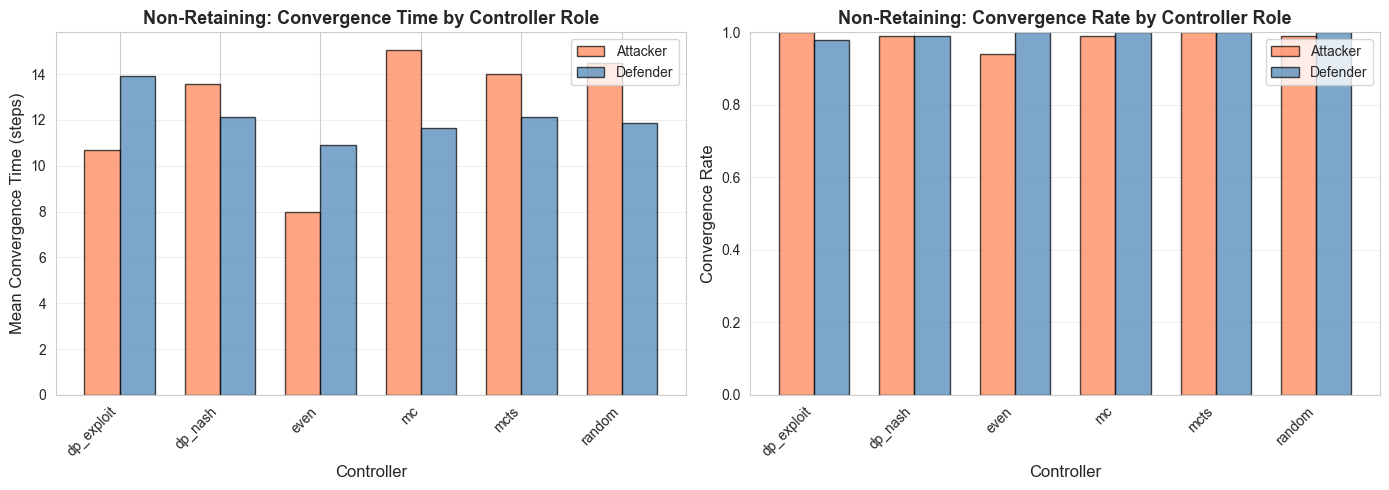

In [42]:
# Visualize controller performance by role (non-retaining)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Mean convergence time by controller and role
controllers = role_summary['controller'].unique()
x = np.arange(len(controllers))
width = 0.35

attacker_means = [role_summary[(role_summary['controller'] == c) & (role_summary['role'] == 'Attacker')]['mean_convergence_time_mean'].values[0] 
                  if len(role_summary[(role_summary['controller'] == c) & (role_summary['role'] == 'Attacker')]) > 0 else 0 
                  for c in controllers]
defender_means = [role_summary[(role_summary['controller'] == c) & (role_summary['role'] == 'Defender')]['mean_convergence_time_mean'].values[0]
                  if len(role_summary[(role_summary['controller'] == c) & (role_summary['role'] == 'Defender')]) > 0 else 0
                  for c in controllers]

bars1 = axes[0].bar(x - width/2, attacker_means, width, label='Attacker', alpha=0.7, edgecolor='black', color='coral')
bars2 = axes[0].bar(x + width/2, defender_means, width, label='Defender', alpha=0.7, edgecolor='black', color='steelblue')

axes[0].set_xlabel('Controller', fontsize=12)
axes[0].set_ylabel('Mean Convergence Time (steps)', fontsize=12)
axes[0].set_title('Non-Retaining: Convergence Time by Controller Role', fontsize=13, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(controllers, rotation=45, ha='right')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Plot 2: Convergence rate by controller and role
attacker_rates = [role_summary[(role_summary['controller'] == c) & (role_summary['role'] == 'Attacker')]['convergence_rate_mean'].values[0]
                  if len(role_summary[(role_summary['controller'] == c) & (role_summary['role'] == 'Attacker')]) > 0 else 0
                  for c in controllers]
defender_rates = [role_summary[(role_summary['controller'] == c) & (role_summary['role'] == 'Defender')]['convergence_rate_mean'].values[0]
                  if len(role_summary[(role_summary['controller'] == c) & (role_summary['role'] == 'Defender')]) > 0 else 0
                  for c in controllers]

bars1 = axes[1].bar(x - width/2, attacker_rates, width, label='Attacker', alpha=0.7, edgecolor='black', color='coral')
bars2 = axes[1].bar(x + width/2, defender_rates, width, label='Defender', alpha=0.7, edgecolor='black', color='steelblue')

axes[1].set_xlabel('Controller', fontsize=12)
axes[1].set_ylabel('Convergence Rate', fontsize=12)
axes[1].set_title('Non-Retaining: Convergence Rate by Controller Role', fontsize=13, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(controllers, rotation=45, ha='right')
axes[1].set_ylim([0, 1.0])
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('plots/nonretaining_controller_role_performance.png', dpi=300, bbox_inches='tight')
plt.show()

## Visualizations

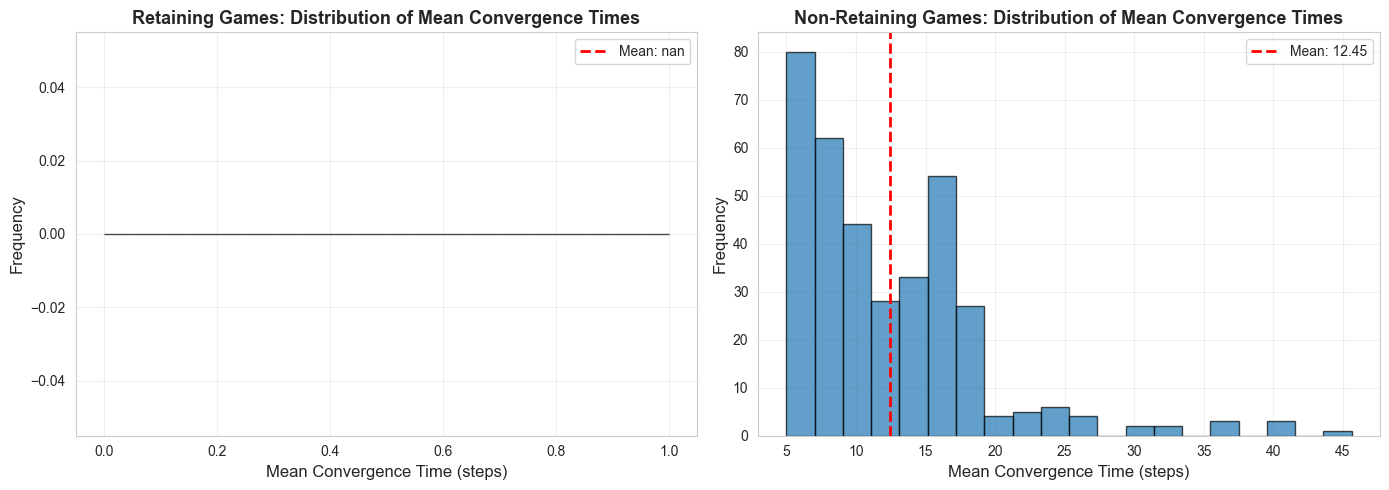

In [32]:
# Plot 1: Distribution of mean convergence times
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, retain in enumerate([True, False]):
    subset = results_df[results_df['retain'] == retain]
    game_type = "Retaining" if retain else "Non-Retaining"
    
    axes[idx].hist(subset['mean_convergence_time'].dropna(), bins=20, alpha=0.7, edgecolor='black')
    axes[idx].axvline(subset['mean_convergence_time'].mean(), color='red', linestyle='--', 
                     linewidth=2, label=f'Mean: {subset["mean_convergence_time"].mean():.2f}')
    axes[idx].set_xlabel('Mean Convergence Time (steps)', fontsize=12)
    axes[idx].set_ylabel('Frequency', fontsize=12)
    axes[idx].set_title(f'{game_type} Games: Distribution of Mean Convergence Times', fontsize=13, fontweight='bold')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plots/convergence_time_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

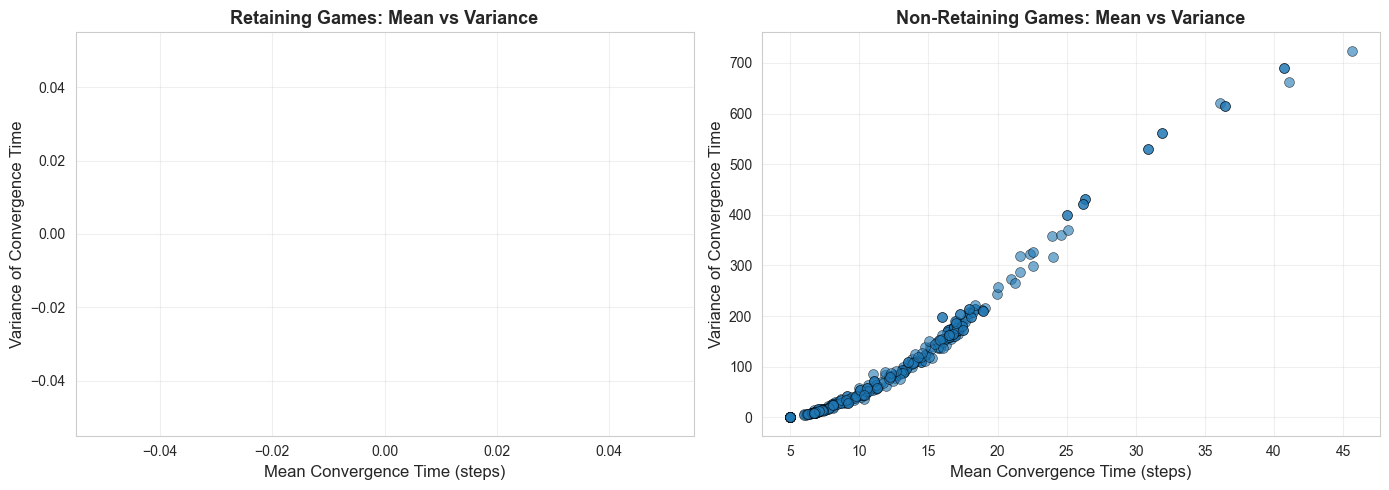

In [33]:
# Plot 2: Mean vs Variance scatter plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, retain in enumerate([True, False]):
    subset = results_df[results_df['retain'] == retain].dropna(subset=['mean_convergence_time', 'variance_convergence_time'])
    game_type = "Retaining" if retain else "Non-Retaining"
    
    axes[idx].scatter(subset['mean_convergence_time'], subset['variance_convergence_time'], 
                     alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
    axes[idx].set_xlabel('Mean Convergence Time (steps)', fontsize=12)
    axes[idx].set_ylabel('Variance of Convergence Time', fontsize=12)
    axes[idx].set_title(f'{game_type} Games: Mean vs Variance', fontsize=13, fontweight='bold')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plots/convergence_mean_vs_variance.png', dpi=300, bbox_inches='tight')
plt.show()

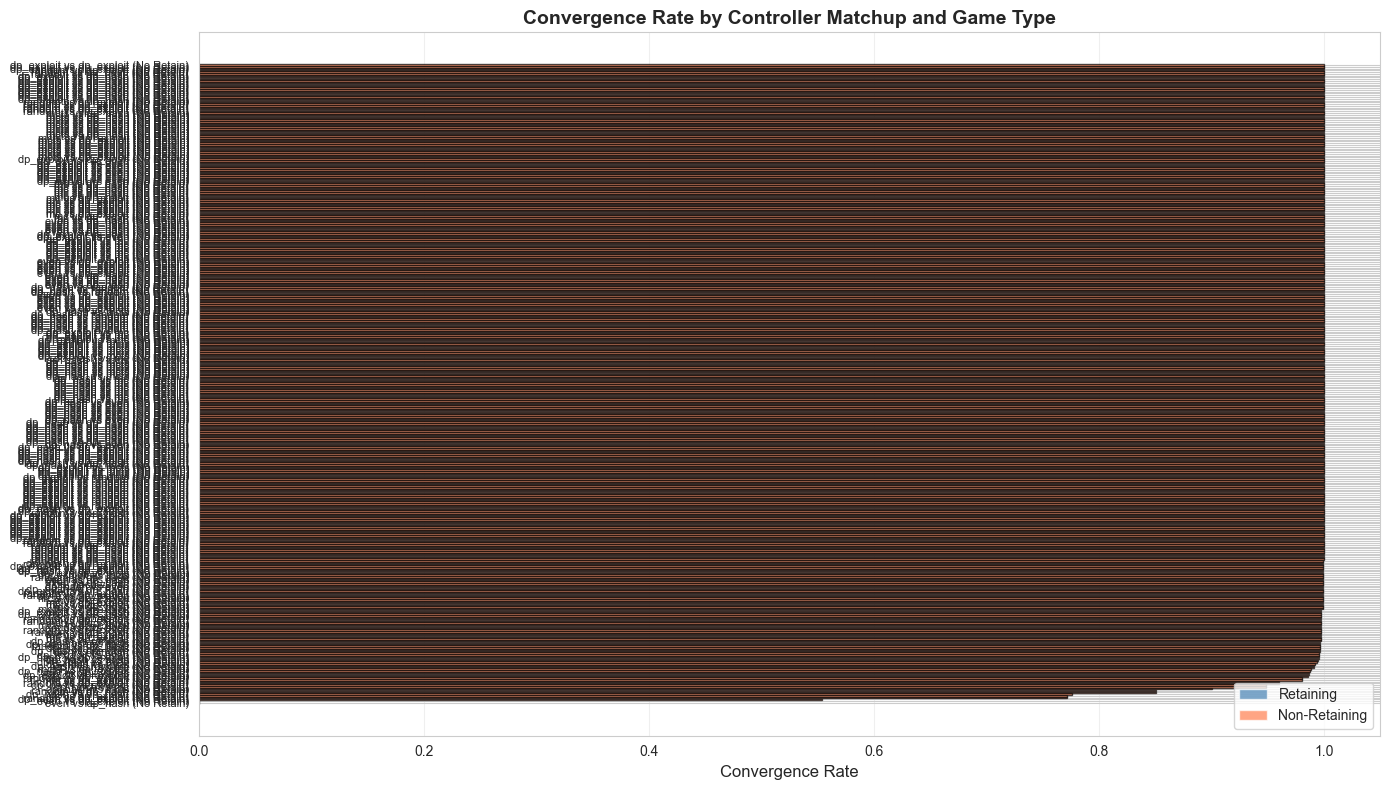

In [34]:
# Plot 3: Convergence rate by matchup
fig, ax = plt.subplots(figsize=(14, 8))

# Create matchup labels
results_df['matchup'] = results_df['attacker'] + ' vs ' + results_df['defender']
results_df['game_type'] = results_df['retain'].map({True: 'Retain', False: 'No Retain'})
results_df['full_label'] = results_df['matchup'] + ' (' + results_df['game_type'] + ')'

# Sort by convergence rate
plot_data = results_df.sort_values('convergence_rate', ascending=True)

# Create bar plot
colors = plot_data['retain'].map({True: 'steelblue', False: 'coral'})
bars = ax.barh(range(len(plot_data)), plot_data['convergence_rate'], color=colors, alpha=0.7, edgecolor='black')

ax.set_yticks(range(len(plot_data)))
ax.set_yticklabels(plot_data['full_label'], fontsize=8)
ax.set_xlabel('Convergence Rate', fontsize=12)
ax.set_title('Convergence Rate by Controller Matchup and Game Type', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='steelblue', alpha=0.7, label='Retaining'),
                   Patch(facecolor='coral', alpha=0.7, label='Non-Retaining')]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig('plots/convergence_rate_by_matchup.png', dpi=300, bbox_inches='tight')
plt.show()

ValueError: Dimensions of labels and X must be compatible

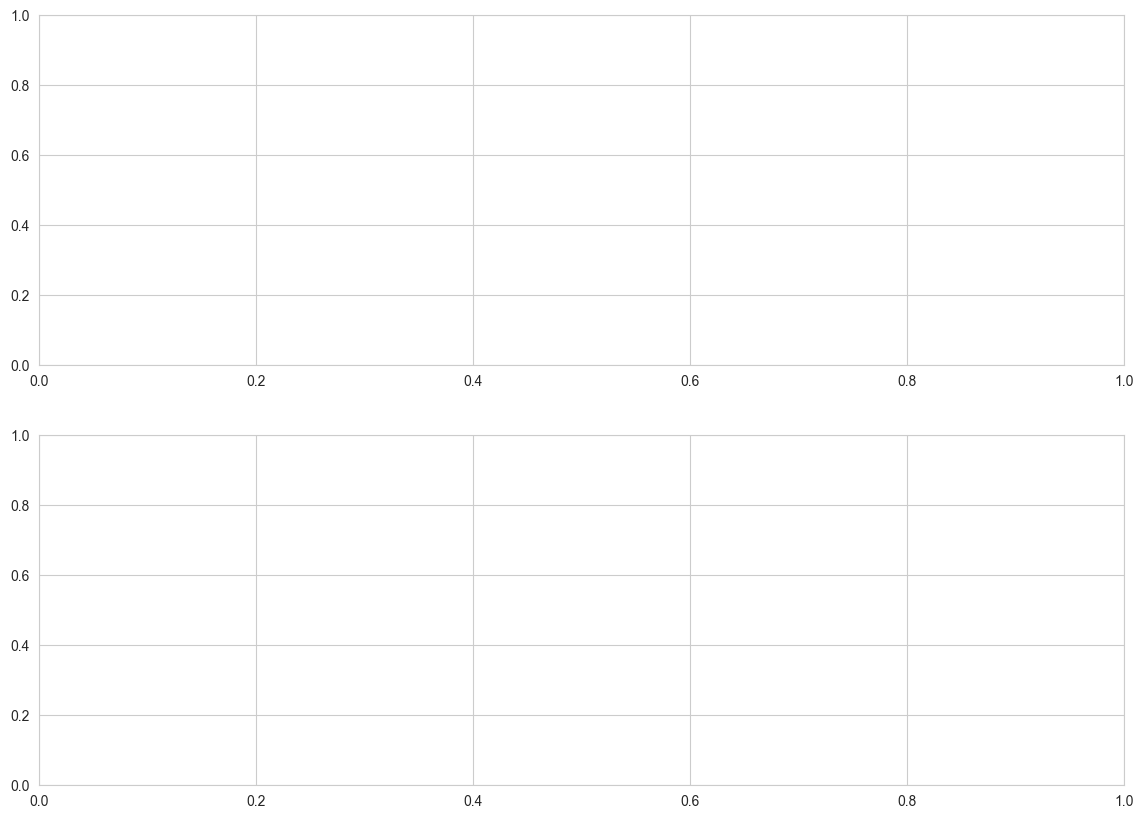

In [21]:
# Plot 4: Box plot of convergence times by controller matchup
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

for idx, retain in enumerate([True, False]):
    subset = results_df[results_df['retain'] == retain]
    game_type = "Retaining" if retain else "Non-Retaining"
    
    # Prepare data for box plot
    matchups = subset['matchup'].unique()
    data_to_plot = [subset[subset['matchup'] == m]['mean_convergence_time'].dropna().values for m in matchups]
    
    bp = axes[idx].boxplot(data_to_plot, labels=matchups, patch_artist=True)
    
    # Color the boxes
    for patch in bp['boxes']:
        patch.set_facecolor('lightblue' if retain else 'lightcoral')
        patch.set_alpha(0.7)
    
    axes[idx].set_ylabel('Mean Convergence Time (steps)', fontsize=12)
    axes[idx].set_title(f'{game_type} Games: Convergence Time Distribution by Matchup', 
                       fontsize=13, fontweight='bold')
    axes[idx].grid(True, alpha=0.3, axis='y')
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('plots/convergence_time_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Plot 5: Effect of parameter variations
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

params = ['alpha', 'm', 'c0']
param_labels = ['Alpha (α)', 'Obedience Utility (m)', 'Initial Capture Rate (c₀)']

for idx, (param, label) in enumerate(zip(params, param_labels)):
    for retain in [True, False]:
        subset = results_df[results_df['retain'] == retain].dropna(subset=['mean_convergence_time'])
        game_type = "Retaining" if retain else "Non-Retaining"
        marker = 'o' if retain else 's'
        
        # Group by parameter and calculate mean
        param_grouped = subset.groupby(param)['mean_convergence_time'].mean()
        
        axes[idx].plot(param_grouped.index, param_grouped.values, marker=marker, 
                      label=game_type, linewidth=2, markersize=8, alpha=0.7)
    
    axes[idx].set_xlabel(label, fontsize=12)
    axes[idx].set_ylabel('Mean Convergence Time (steps)', fontsize=12)
    axes[idx].set_title(f'Effect of {label} on Convergence Time', fontsize=12, fontweight='bold')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plots/parameter_effects.png', dpi=300, bbox_inches='tight')
plt.show()

## Export Results

In [ ]:
# Save detailed results to CSV
output_file = 'convergence_analysis_results.csv'
results_df.to_csv(output_file, index=False)
print(f"Results saved to: {output_file}")

# Save summary statistics
summary_file = 'convergence_analysis_summary.csv'
matchup_summary.to_csv(summary_file, index=False)
print(f"Summary statistics saved to: {summary_file}")

---
# Retaining Games Analysis

Now analyzing retaining games with the same controller filter (dp_exploit and dp_nash).

In [35]:
# Get retaining game files with dp_exploit and dp_nash
retaining_csv_files = [f for f in all_csv_files if 
                       ('dp_exploit' in f.name or 'dp_nash' in f.name) and 
                       'retain-True' in f.name]
print(f"Found {len(retaining_csv_files)} retaining files with dp_exploit or dp_nash controllers")

# Show all filenames
print("\nRetaining game files to analyze:")
for f in retaining_csv_files:
    print(f"  {f.name}")

Found 360 retaining files with dp_exploit or dp_nash controllers

Retaining game files to analyze:
  att-dp_exploit__def-dp_exploit__sims-1000__steps-100__natt-10__ndef-10__m-0.25__p-1.0__alpha-0.5__c0-0.25__retain-True.csv
  att-dp_exploit__def-dp_exploit__sims-1000__steps-100__natt-10__ndef-10__m-0.5__p-1.0__alpha-0.1__c0-0.25__retain-True.csv
  att-dp_exploit__def-dp_exploit__sims-1000__steps-100__natt-10__ndef-10__m-0.5__p-1.0__alpha-0.3__c0-0.25__retain-True.csv
  att-dp_exploit__def-dp_exploit__sims-1000__steps-100__natt-10__ndef-10__m-0.5__p-1.0__alpha-0.5__c0-0.0__retain-True.csv
  att-dp_exploit__def-dp_exploit__sims-1000__steps-100__natt-10__ndef-10__m-0.5__p-1.0__alpha-0.5__c0-0.25__retain-True.csv
  att-dp_exploit__def-dp_exploit__sims-1000__steps-100__natt-10__ndef-10__m-0.5__p-1.0__alpha-0.5__c0-0.5__retain-True.csv
  att-dp_exploit__def-dp_exploit__sims-1000__steps-100__natt-10__ndef-10__m-0.5__p-1.0__alpha-0.7__c0-0.25__retain-True.csv
  att-dp_exploit__def-dp_exploit__

In [36]:
# Analyze retaining game files
print("Analyzing convergence for retaining games...")
retaining_results = []

for i, filepath in enumerate(retaining_csv_files):
    if (i + 1) % 5 == 0:
        print(f"  Processed {i + 1}/{len(retaining_csv_files)} files...")
    
    try:
        result = analyze_convergence_for_file(filepath)
        retaining_results.append(result)
    except Exception as e:
        print(f"  Error processing {filepath.name}: {e}")

print(f"\nCompleted analysis of {len(retaining_results)} retaining game files")

# Create results dataframe
retaining_results_df = pd.DataFrame(retaining_results)
retaining_results_df.head(10)

Analyzing convergence for retaining games...
  Processed 5/360 files...
  Processed 10/360 files...
  Processed 15/360 files...
  Processed 20/360 files...
  Processed 25/360 files...
  Processed 30/360 files...
  Processed 35/360 files...
  Processed 40/360 files...
  Processed 45/360 files...
  Processed 50/360 files...
  Processed 55/360 files...
  Processed 60/360 files...
  Processed 65/360 files...
  Processed 70/360 files...
  Processed 75/360 files...
  Processed 80/360 files...
  Processed 85/360 files...
  Processed 90/360 files...
  Processed 95/360 files...
  Processed 100/360 files...
  Processed 105/360 files...
  Processed 110/360 files...
  Processed 115/360 files...
  Processed 120/360 files...
  Processed 125/360 files...
  Processed 130/360 files...
  Processed 135/360 files...
  Processed 140/360 files...
  Processed 145/360 files...
  Processed 150/360 files...
  Processed 155/360 files...
  Processed 160/360 files...
  Processed 165/360 files...
  Processed 170/36

,filename,attacker,defender,retain,alpha,m,c0,total_sims,converged_sims,convergence_rate,mean_convergence_time,variance_convergence_time,std_convergence_time,median_convergence_time,min_convergence_time,max_convergence_time
0,att-dp_exploit__def-dp_exploit__sims-1000__ste...,dp_exploit,dp_exploit,True,0.5,0.25,0.25,1000,1000,1.0,5.758,1.103436,1.050446,5.0,5,9
1,att-dp_exploit__def-dp_exploit__sims-1000__ste...,dp_exploit,dp_exploit,True,0.1,0.50,0.25,1000,1000,1.0,5.758,1.103436,1.050446,5.0,5,9
2,att-dp_exploit__def-dp_exploit__sims-1000__ste...,dp_exploit,dp_exploit,True,0.3,0.50,0.25,1000,1000,1.0,5.758,1.103436,1.050446,5.0,5,9
3,att-dp_exploit__def-dp_exploit__sims-1000__ste...,dp_exploit,dp_exploit,True,0.5,0.50,0.00,1000,1000,1.0,5.758,1.103436,1.050446,5.0,5,9
4,att-dp_exploit__def-dp_exploit__sims-1000__ste...,dp_exploit,dp_exploit,True,0.5,0.50,0.25,1000,1000,1.0,5.758,1.103436,1.050446,5.0,5,9
5,att-dp_exploit__def-dp_exploit__sims-1000__ste...,dp_exploit,dp_exploit,True,0.5,0.50,0.50,1000,1000,1.0,5.758,1.103436,1.050446,5.0,5,9
6,att-dp_exploit__def-dp_exploit__sims-1000__ste...,dp_exploit,dp_exploit,True,0.7,0.50,0.25,1000,1000,1.0,5.758,1.103436,1.050446,5.0,5,9
7,att-dp_exploit__def-dp_exploit__sims-1000__ste...,dp_exploit,dp_exploit,True,0.9,0.50,0.25,1000,1000,1.0,5.758,1.103436,1.050446,5.0,5,9
8,att-dp_exploit__def-dp_exploit__sims-1000__ste...,dp_exploit,dp_exploit,True,0.5,0.75,0.25,1000,1000,1.0,5.758,1.103436,1.050446,5.0,5,9
9,att-dp_exploit__def-dp_exploit__sims-1000__ste...,dp_exploit,dp_exploit,True,0.5,1.00,0.25,1000,1000,1.0,5.758,1.103436,1.050446,5.0,5,9


In [37]:
# Retaining games summary statistics
print("="*80)
print("RETAINING GAMES CONVERGENCE SUMMARY")
print("="*80)
print(f"\nTotal retaining configurations analyzed: {len(retaining_results_df)}")
print(f"Average convergence rate: {retaining_results_df['convergence_rate'].mean():.2%}")
print(f"\nMean convergence time: {retaining_results_df['mean_convergence_time'].mean():.2f} ± {retaining_results_df['mean_convergence_time'].std():.2f} steps")
print(f"Mean variance: {retaining_results_df['variance_convergence_time'].mean():.2f}")
print(f"Range: [{retaining_results_df['mean_convergence_time'].min():.2f}, {retaining_results_df['mean_convergence_time'].max():.2f}] steps")

# Summary by controller matchup
print("\n" + "="*80)
print("CONVERGENCE TIME BY CONTROLLER MATCHUP (RETAINING)")
print("="*80)

retaining_matchup_summary = retaining_results_df.groupby(['attacker', 'defender']).agg({
    'mean_convergence_time': ['mean', 'std', 'count'],
    'variance_convergence_time': 'mean',
    'convergence_rate': 'mean'
}).round(2)

retaining_matchup_summary.columns = ['_'.join(col).strip() for col in retaining_matchup_summary.columns.values]
retaining_matchup_summary = retaining_matchup_summary.reset_index()
retaining_matchup_summary = retaining_matchup_summary.sort_values('mean_convergence_time_mean')

print(retaining_matchup_summary.to_string())

RETAINING GAMES CONVERGENCE SUMMARY

Total retaining configurations analyzed: 360
Average convergence rate: 100.00%

Mean convergence time: 6.27 ± 0.48 steps
Mean variance: 0.99
Range: [5.04, 8.21] steps

CONVERGENCE TIME BY CONTROLLER MATCHUP (RETAINING)
               attacker             defender  mean_convergence_time_mean  mean_convergence_time_std  mean_convergence_time_count  variance_convergence_time_mean  convergence_rate_mean
0            dp_exploit           dp_exploit                        5.76                       0.00                           18                            1.10                    1.0
5            dp_exploit  retaining_heuristic                        5.82                       0.01                           18                            1.12                    1.0
18  retaining_heuristic           dp_exploit                        5.82                       0.02                           18                            1.21                    1.0
1       

In [ ]:
# Summary by controller role (attacker vs defender) for retaining games
print("\n" + "="*80)
print("CONVERGENCE TIME BY CONTROLLER AND ROLE (RETAINING)")
print("="*80)

# Attacker analysis
retaining_attacker_summary = retaining_results_df.groupby('attacker').agg({
    'mean_convergence_time': ['mean', 'std', 'count'],
    'variance_convergence_time': 'mean',
    'convergence_rate': 'mean'
}).round(2)
retaining_attacker_summary.columns = ['_'.join(col).strip() for col in retaining_attacker_summary.columns.values]
retaining_attacker_summary = retaining_attacker_summary.reset_index()
retaining_attacker_summary['role'] = 'Attacker'
retaining_attacker_summary = retaining_attacker_summary.rename(columns={'attacker': 'controller'})

# Defender analysis
retaining_defender_summary = retaining_results_df.groupby('defender').agg({
    'mean_convergence_time': ['mean', 'std', 'count'],
    'variance_convergence_time': 'mean',
    'convergence_rate': 'mean'
}).round(2)
retaining_defender_summary.columns = ['_'.join(col).strip() for col in retaining_defender_summary.columns.values]
retaining_defender_summary = retaining_defender_summary.reset_index()
retaining_defender_summary['role'] = 'Defender'
retaining_defender_summary = retaining_defender_summary.rename(columns={'defender': 'controller'})

# Combine both
retaining_role_summary = pd.concat([retaining_attacker_summary, retaining_defender_summary], ignore_index=True)
retaining_role_summary = retaining_role_summary.sort_values(['controller', 'role'])

print("\nController performance by role:")
print(retaining_role_summary.to_string(index=False))

# Calculate difference between attacker and defender performance for each controller
print("\n" + "="*80)
print("ATTACKER vs DEFENDER PERFORMANCE GAP (RETAINING)")
print("="*80)
for controller in retaining_role_summary['controller'].unique():
    att_data = retaining_role_summary[(retaining_role_summary['controller'] == controller) & (retaining_role_summary['role'] == 'Attacker')]
    def_data = retaining_role_summary[(retaining_role_summary['controller'] == controller) & (retaining_role_summary['role'] == 'Defender')]
    
    if not att_data.empty and not def_data.empty:
        att_mean = att_data['mean_convergence_time_mean'].values[0]
        def_mean = def_data['mean_convergence_time_mean'].values[0]
        diff = att_mean - def_mean
        
        att_rate = att_data['convergence_rate_mean'].values[0]
        def_rate = def_data['convergence_rate_mean'].values[0]
        rate_diff = att_rate - def_rate
        
        print(f"\n{controller}:")
        print(f"  Convergence time difference (Att - Def): {diff:+.2f} steps")
        print(f"  Convergence rate difference (Att - Def): {rate_diff:+.2%}")
        print(f"  Faster when: {'Attacking' if diff < 0 else 'Defending' if diff > 0 else 'Equal'}")

In [ ]:
# Visualize controller performance by role (retaining)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Mean convergence time by controller and role
controllers = retaining_role_summary['controller'].unique()
x = np.arange(len(controllers))
width = 0.35

attacker_means = [retaining_role_summary[(retaining_role_summary['controller'] == c) & (retaining_role_summary['role'] == 'Attacker')]['mean_convergence_time_mean'].values[0]
                  if len(retaining_role_summary[(retaining_role_summary['controller'] == c) & (retaining_role_summary['role'] == 'Attacker')]) > 0 else 0
                  for c in controllers]
defender_means = [retaining_role_summary[(retaining_role_summary['controller'] == c) & (retaining_role_summary['role'] == 'Defender')]['mean_convergence_time_mean'].values[0]
                  if len(retaining_role_summary[(retaining_role_summary['controller'] == c) & (retaining_role_summary['role'] == 'Defender')]) > 0 else 0
                  for c in controllers]

bars1 = axes[0].bar(x - width/2, attacker_means, width, label='Attacker', alpha=0.7, edgecolor='black', color='coral')
bars2 = axes[0].bar(x + width/2, defender_means, width, label='Defender', alpha=0.7, edgecolor='black', color='steelblue')

axes[0].set_xlabel('Controller', fontsize=12)
axes[0].set_ylabel('Mean Convergence Time (steps)', fontsize=12)
axes[0].set_title('Retaining: Convergence Time by Controller Role', fontsize=13, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(controllers, rotation=45, ha='right')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Plot 2: Convergence rate by controller and role
attacker_rates = [retaining_role_summary[(retaining_role_summary['controller'] == c) & (retaining_role_summary['role'] == 'Attacker')]['convergence_rate_mean'].values[0]
                  if len(retaining_role_summary[(retaining_role_summary['controller'] == c) & (retaining_role_summary['role'] == 'Attacker')]) > 0 else 0
                  for c in controllers]
defender_rates = [retaining_role_summary[(retaining_role_summary['controller'] == c) & (retaining_role_summary['role'] == 'Defender')]['convergence_rate_mean'].values[0]
                  if len(retaining_role_summary[(retaining_role_summary['controller'] == c) & (retaining_role_summary['role'] == 'Defender')]) > 0 else 0
                  for c in controllers]

bars1 = axes[1].bar(x - width/2, attacker_rates, width, label='Attacker', alpha=0.7, edgecolor='black', color='coral')
bars2 = axes[1].bar(x + width/2, defender_rates, width, label='Defender', alpha=0.7, edgecolor='black', color='steelblue')

axes[1].set_xlabel('Controller', fontsize=12)
axes[1].set_ylabel('Convergence Rate', fontsize=12)
axes[1].set_title('Retaining: Convergence Rate by Controller Role', fontsize=13, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(controllers, rotation=45, ha='right')
axes[1].set_ylim([0, 1.0])
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('plots/retaining_controller_role_performance.png', dpi=300, bbox_inches='tight')
plt.show()

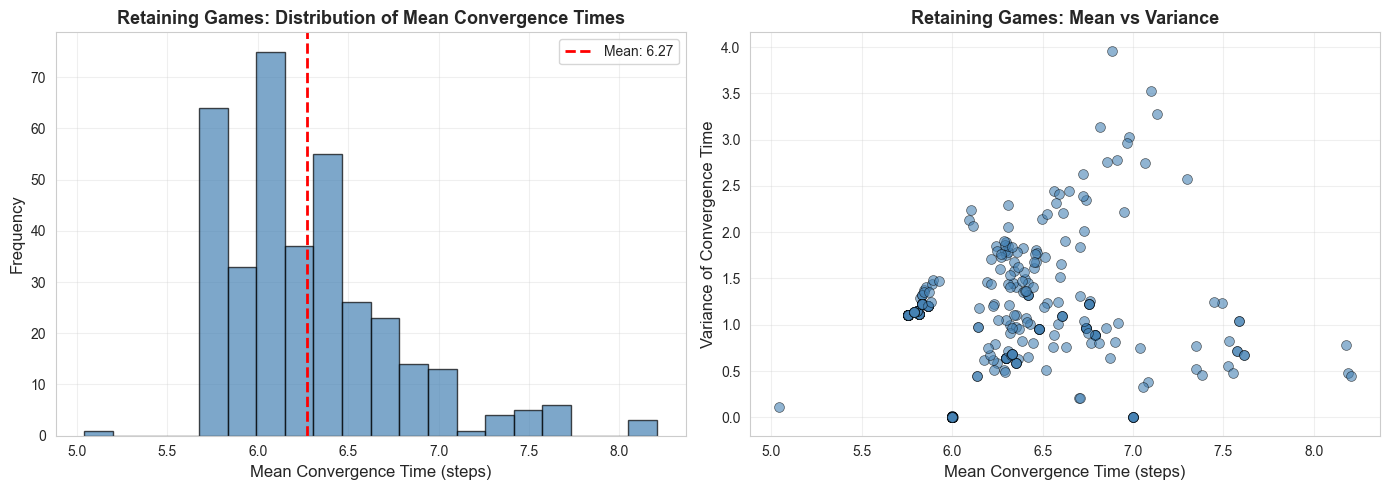

In [38]:
# Retaining games visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Distribution of mean convergence times
axes[0].hist(retaining_results_df['mean_convergence_time'].dropna(), bins=20, alpha=0.7, 
             edgecolor='black', color='steelblue')
axes[0].axvline(retaining_results_df['mean_convergence_time'].mean(), color='red', linestyle='--', 
                linewidth=2, label=f'Mean: {retaining_results_df["mean_convergence_time"].mean():.2f}')
axes[0].set_xlabel('Mean Convergence Time (steps)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Retaining Games: Distribution of Mean Convergence Times', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Mean vs Variance scatter plot
subset = retaining_results_df.dropna(subset=['mean_convergence_time', 'variance_convergence_time'])
axes[1].scatter(subset['mean_convergence_time'], subset['variance_convergence_time'], 
                alpha=0.6, s=50, edgecolors='black', linewidth=0.5, color='steelblue')
axes[1].set_xlabel('Mean Convergence Time (steps)', fontsize=12)
axes[1].set_ylabel('Variance of Convergence Time', fontsize=12)
axes[1].set_title('Retaining Games: Mean vs Variance', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plots/retaining_convergence_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

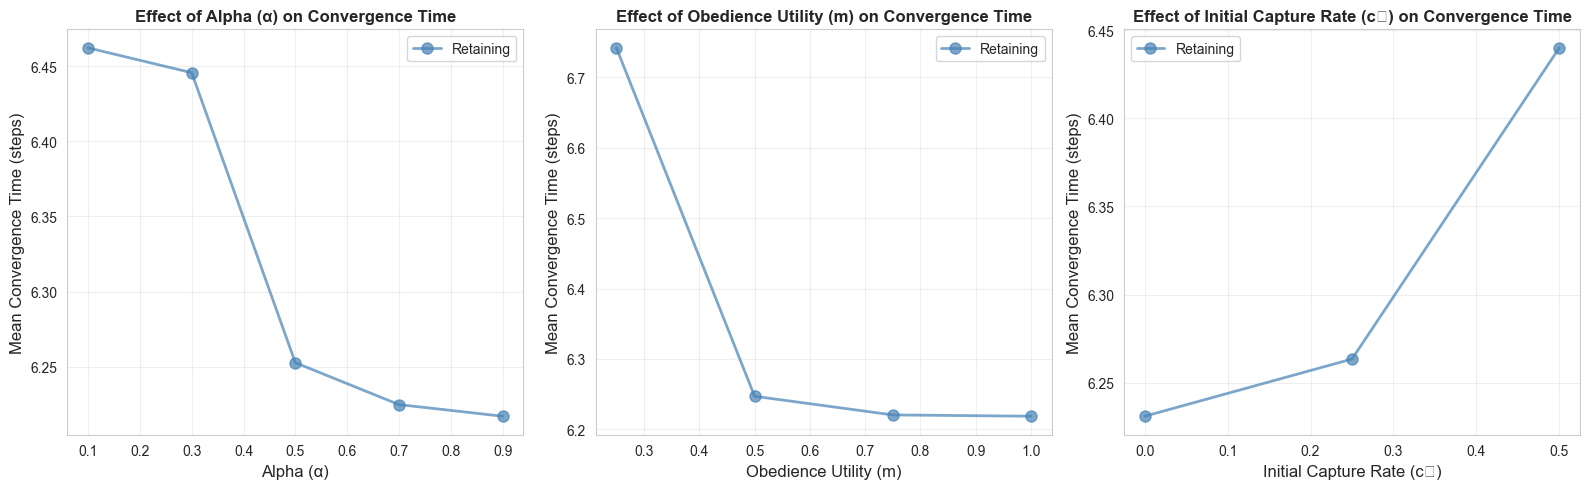

In [39]:
# Retaining games: Effect of parameter variations
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

params = ['alpha', 'm', 'c0']
param_labels = ['Alpha (α)', 'Obedience Utility (m)', 'Initial Capture Rate (c₀)']

for idx, (param, label) in enumerate(zip(params, param_labels)):
    subset = retaining_results_df.dropna(subset=['mean_convergence_time'])
    
    # Group by parameter and calculate mean
    param_grouped = subset.groupby(param)['mean_convergence_time'].mean()
    
    axes[idx].plot(param_grouped.index, param_grouped.values, marker='o', 
                  label='Retaining', linewidth=2, markersize=8, alpha=0.7, color='steelblue')
    
    axes[idx].set_xlabel(label, fontsize=12)
    axes[idx].set_ylabel('Mean Convergence Time (steps)', fontsize=12)
    axes[idx].set_title(f'Effect of {label} on Convergence Time', fontsize=12, fontweight='bold')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plots/retaining_parameter_effects.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Save retaining games results to CSV
retaining_output_file = 'convergence_analysis_retaining_results.csv'
retaining_results_df.to_csv(retaining_output_file, index=False)
print(f"Retaining games results saved to: {retaining_output_file}")

# Save summary statistics
retaining_summary_file = 'convergence_analysis_retaining_summary.csv'
retaining_matchup_summary.to_csv(retaining_summary_file, index=False)
print(f"Retaining games summary statistics saved to: {retaining_summary_file}")

## Comparison: Retaining vs Non-Retaining Games

COMPARISON: RETAINING vs NON-RETAINING GAMES

Non-Retaining Games:
  Configurations: 360
  Mean convergence time: 12.45 ± 6.61 steps
  Convergence rate: 98.91%

Retaining Games:
  Configurations: 360
  Mean convergence time: 6.27 ± 0.48 steps
  Convergence rate: 100.00%


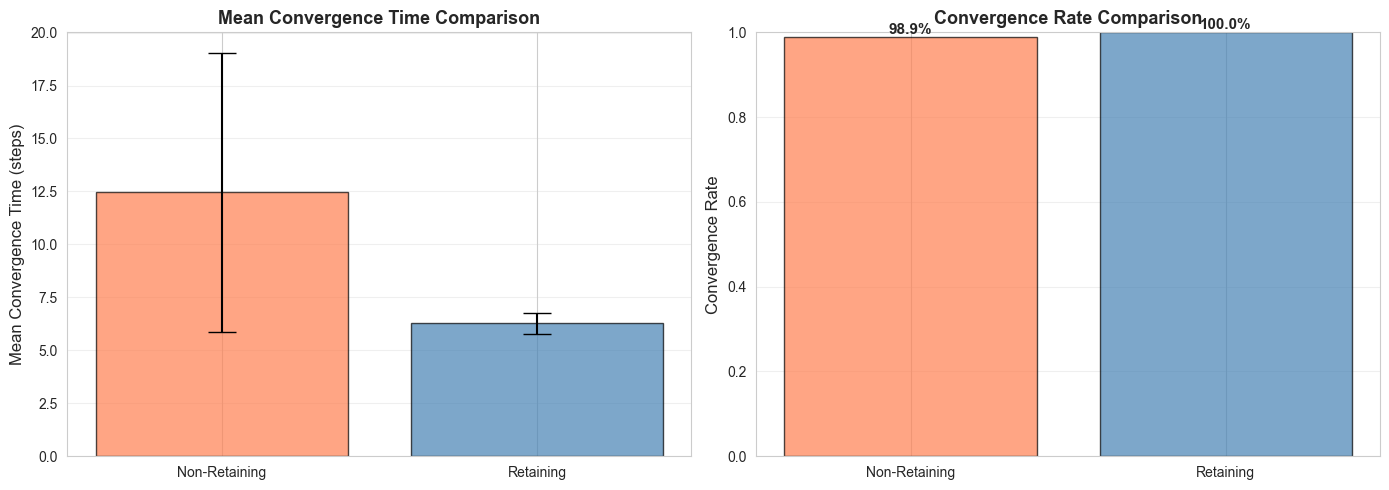

In [40]:
# Combine both datasets for comparison
combined_df = pd.concat([results_df, retaining_results_df], ignore_index=True)

# Comparison summary
print("="*80)
print("COMPARISON: RETAINING vs NON-RETAINING GAMES")
print("="*80)
print("\nNon-Retaining Games:")
print(f"  Configurations: {len(results_df)}")
print(f"  Mean convergence time: {results_df['mean_convergence_time'].mean():.2f} ± {results_df['mean_convergence_time'].std():.2f} steps")
print(f"  Convergence rate: {results_df['convergence_rate'].mean():.2%}")

print("\nRetaining Games:")
print(f"  Configurations: {len(retaining_results_df)}")
print(f"  Mean convergence time: {retaining_results_df['mean_convergence_time'].mean():.2f} ± {retaining_results_df['mean_convergence_time'].std():.2f} steps")
print(f"  Convergence rate: {retaining_results_df['convergence_rate'].mean():.2%}")

# Side-by-side comparison plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Mean convergence time comparison
game_types = ['Non-Retaining', 'Retaining']
means = [results_df['mean_convergence_time'].mean(), retaining_results_df['mean_convergence_time'].mean()]
stds = [results_df['mean_convergence_time'].std(), retaining_results_df['mean_convergence_time'].std()]

bars = axes[0].bar(game_types, means, yerr=stds, alpha=0.7, 
                   color=['coral', 'steelblue'], edgecolor='black', capsize=10)
axes[0].set_ylabel('Mean Convergence Time (steps)', fontsize=12)
axes[0].set_title('Mean Convergence Time Comparison', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# Plot 2: Convergence rate comparison
conv_rates = [results_df['convergence_rate'].mean(), retaining_results_df['convergence_rate'].mean()]
bars = axes[1].bar(game_types, conv_rates, alpha=0.7, 
                   color=['coral', 'steelblue'], edgecolor='black')
axes[1].set_ylabel('Convergence Rate', fontsize=12)
axes[1].set_title('Convergence Rate Comparison', fontsize=13, fontweight='bold')
axes[1].set_ylim([0, 1.0])
axes[1].grid(True, alpha=0.3, axis='y')

# Add percentage labels on bars
for i, (bar, rate) in enumerate(zip(bars, conv_rates)):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{rate:.1%}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('plots/retaining_vs_nonretaining_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Role-based comparison across game types
print("="*80)
print("ROLE PERFORMANCE SUMMARY: RETAINING vs NON-RETAINING")
print("="*80)

# Combine role summaries with game type labels
role_summary_combined = role_summary.copy()
role_summary_combined['game_type'] = 'Non-Retaining'

retaining_role_summary_combined = retaining_role_summary.copy()
retaining_role_summary_combined['game_type'] = 'Retaining'

all_role_summary = pd.concat([role_summary_combined, retaining_role_summary_combined], ignore_index=True)

# Create pivot table for easier comparison
pivot_convergence = all_role_summary.pivot_table(
    index=['controller', 'role'],
    columns='game_type',
    values='mean_convergence_time_mean'
).round(2)

pivot_rate = all_role_summary.pivot_table(
    index=['controller', 'role'],
    columns='game_type',
    values='convergence_rate_mean'
).round(3)

print("\nMean Convergence Time by Controller, Role, and Game Type:")
print(pivot_convergence.to_string())

print("\n\nConvergence Rate by Controller, Role, and Game Type:")
print(pivot_rate.to_string())

# Visualize the comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Get unique controllers
all_controllers = all_role_summary['controller'].unique()

# Plot convergence time comparison
for controller in all_controllers:
    subset = all_role_summary[all_role_summary['controller'] == controller]
    
    for role, marker, color in [('Attacker', 'o', 'coral'), ('Defender', 's', 'steelblue')]:
        role_data = subset[subset['role'] == role]
        if len(role_data) > 0:
            game_types = role_data['game_type'].values
            conv_times = role_data['mean_convergence_time_mean'].values
            
            label = f"{controller} ({role})"
            axes[0].plot(game_types, conv_times, marker=marker, markersize=10, 
                        linewidth=2, alpha=0.7, label=label, color=color if 'exploit' in controller else 'green')

axes[0].set_xlabel('Game Type', fontsize=12)
axes[0].set_ylabel('Mean Convergence Time (steps)', fontsize=12)
axes[0].set_title('Controller Role Performance Across Game Types', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Plot convergence rate comparison
for controller in all_controllers:
    subset = all_role_summary[all_role_summary['controller'] == controller]
    
    for role, marker, color in [('Attacker', 'o', 'coral'), ('Defender', 's', 'steelblue')]:
        role_data = subset[subset['role'] == role]
        if len(role_data) > 0:
            game_types = role_data['game_type'].values
            conv_rates = role_data['convergence_rate_mean'].values
            
            label = f"{controller} ({role})"
            axes[1].plot(game_types, conv_rates, marker=marker, markersize=10,
                        linewidth=2, alpha=0.7, label=label, color=color if 'exploit' in controller else 'green')

axes[1].set_xlabel('Game Type', fontsize=12)
axes[1].set_ylabel('Convergence Rate', fontsize=12)
axes[1].set_title('Controller Role Convergence Rate Across Game Types', fontsize=13, fontweight='bold')
axes[1].set_ylim([0, 1.0])
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plots/role_performance_across_game_types.png', dpi=300, bbox_inches='tight')
plt.show()

## Key Findings

Run all cells above to populate this with specific findings from your data.